# MC62 Shims Effect: 01 (with) vs 02 (without)

| Dataset | Source |
|---------|--------|
| **Test 01 (with shims)** | `MC62/01_with_shims` |
| **Test 02 (without shims)** | `MC62/02_without_shims` |

| # | Section |
|---|---------|
| 1 | Configuration & Imports |
| 2 | Load Summary CSVs |
| 3 | Overview |
| 4 | B1 Overlay |
| 5 | b2 Overlay |
| 6 | b3 Overlay |
| 7 | Transfer Function Overlay |
| 8 | Per-Level Differences |
| 9 | Multipole Spectrum Comparison |
| 10 | Summary |

---
## 1. Configuration & Imports

In [1]:
SEGMENTS = ['Integral', 'Central']

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib widget
plt.rcParams.update({"figure.figsize": (14, 5), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})

REPO_ROOT = Path(".").resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "pyproject.toml").exists() or (REPO_ROOT / ".git").exists(): break
    REPO_ROOT = REPO_ROOT.parent

OUT_0 = REPO_ROOT / "output" / "MC62/01_with_shims"
OUT_1 = REPO_ROOT / "output" / "MC62/02_without_shims"
assert OUT_0.exists(), f"Test 01 (with shims) output not found: {OUT_0}"
assert OUT_1.exists(), f"Test 02 (without shims) output not found: {OUT_1}"

DS_DIRS = [("Test 01 (with shims)", OUT_0), ("Test 02 (without shims)", OUT_1)]
print("Comparison: MC62 Shims Effect: 01 (with) vs 02 (without)")
for name, p in DS_DIRS:
    print(f"  {name}: {p}")

Comparison: MC62 Shims Effect: 01 (with) vs 02 (without)
  Test 01 (with shims): C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MC62\01_with_shims
  Test 02 (without shims): C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MC62\02_without_shims


---
## 2. Load Summary CSVs

In [2]:
summ = {}
for name, out_dir in DS_DIRS:
    summ[name] = {}
    for seg in SEGMENTS:
        fname = f"MC62_{seg}_summary.csv"
        fpath = out_dir / fname
        assert fpath.exists(), f"Missing: {fpath}"
        df = pd.read_csv(fpath)
        summ[name][seg] = df
        good = df[df["quality"] == "good"]
        print(f"  {name} {seg}: {len(df)} runs ({len(good)} good)")

  Test 01 (with shims) Integral: 41 runs (41 good)
  Test 01 (with shims) Central: 41 runs (41 good)
  Test 02 (without shims) Integral: 41 runs (41 good)
  Test 02 (without shims) Central: 41 runs (41 good)


---
## 3. Overview

In [3]:
print(f"{'Dataset':<30s}  {'Segment':<12s}  {'Runs':>5s}  {'Good':>5s}  {'I range':>10s}")
print("=" * 75)
for name, _ in DS_DIRS:
    for seg in SEGMENTS:
        s = summ[name][seg]
        good = s[s["quality"] == "good"]
        I_lo = good["I_nom"].min() if len(good) else 0
        I_hi = good["I_nom"].max() if len(good) else 0
        print(f"  {name:<28s}  {seg:<12s}  {len(s):>5d}  {len(good):>5d}  "
              f"{I_lo:>+.0f} to {I_hi:>+.0f} A")

Dataset                         Segment        Runs   Good     I range
  Test 01 (with shims)          Integral         41     41  -200 to +200 A
  Test 01 (with shims)          Central          41     41  -200 to +200 A
  Test 02 (without shims)       Integral         41     41  -200 to +200 A
  Test 02 (without shims)       Central          41     41  -200 to +200 A


---
## 4. B1 Overlay

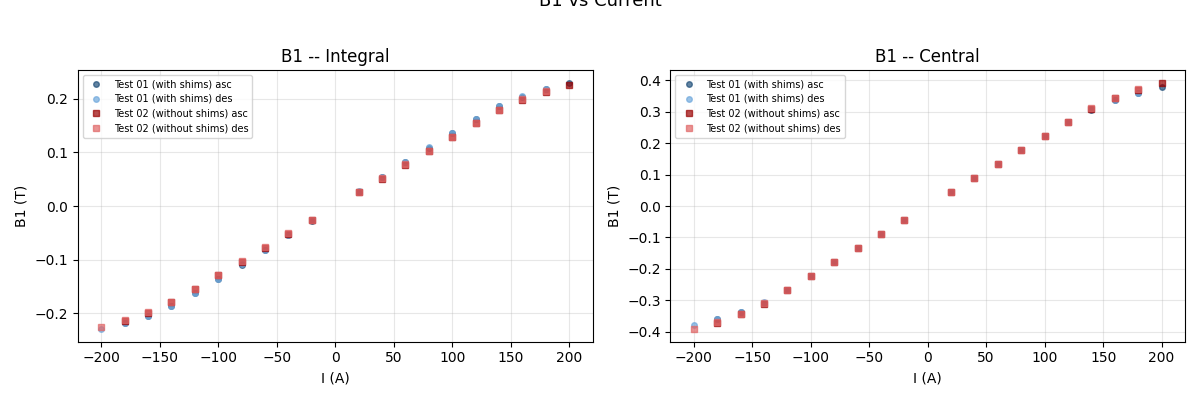

In [4]:
fig, axes = plt.subplots(1, len(SEGMENTS), figsize=(12, 4), squeeze=False)

DS_STYLES = [
    ("o", "#1f4e79", "#6fa8dc"),   # first dataset
    ("s", "#990000", "#e06666"),   # second dataset
]

for j, seg in enumerate(SEGMENTS):
    ax = axes[0, j]
    for k, (name, _) in enumerate(DS_DIRS):
        marker, c_asc, c_desc = DS_STYLES[k]
        s = summ[name][seg].copy()
        good = s[(s["quality"] == "good") & (s["I_nom"].abs() > 2)]
        for br, color in [("ascending", c_asc), ("descending", c_desc)]:
            br_data = good[good["branch"] == br].sort_values("run_id")
            if len(br_data) == 0: continue
            I_vals = br_data["I_nom"].values
            breaks = [0] + [i for i in range(1, len(I_vals))
                            if abs(I_vals[i] - I_vals[i-1]) > 30] + [len(I_vals)]
            for bi in range(len(breaks)-1):
                seg_data = br_data.iloc[breaks[bi]:breaks[bi+1]]
                ax.plot(seg_data["I_nom"], seg_data["B1_mean"],
                        marker=marker, ms=4, lw=0, alpha=0.7, color=color,
                        label=f"{name} {br[:3]}" if bi == 0 else "")
    ax.set_xlabel("I (A)"); ax.set_ylabel("B1 (T)")
    ax.set_title(f"B1 -- {seg}")
    ax.legend(fontsize=7, loc="best")

fig.suptitle("B1 vs Current", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 5. b2 Overlay

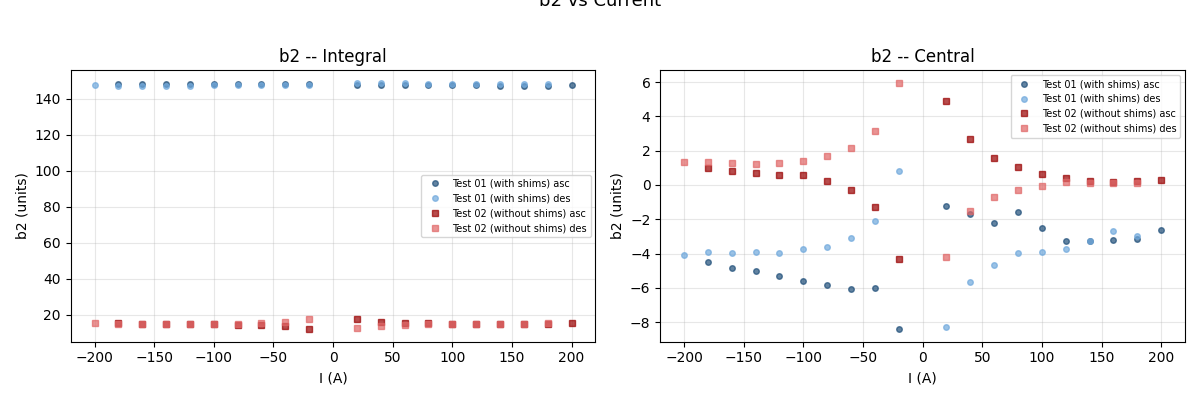

In [5]:
fig, axes = plt.subplots(1, len(SEGMENTS), figsize=(12, 4), squeeze=False)

DS_STYLES = [
    ("o", "#1f4e79", "#6fa8dc"),   # first dataset
    ("s", "#990000", "#e06666"),   # second dataset
]

for j, seg in enumerate(SEGMENTS):
    ax = axes[0, j]
    for k, (name, _) in enumerate(DS_DIRS):
        marker, c_asc, c_desc = DS_STYLES[k]
        s = summ[name][seg].copy()
        good = s[(s["quality"] == "good") & (s["I_nom"].abs() > 2)]
        for br, color in [("ascending", c_asc), ("descending", c_desc)]:
            br_data = good[good["branch"] == br].sort_values("run_id")
            if len(br_data) == 0: continue
            I_vals = br_data["I_nom"].values
            breaks = [0] + [i for i in range(1, len(I_vals))
                            if abs(I_vals[i] - I_vals[i-1]) > 30] + [len(I_vals)]
            for bi in range(len(breaks)-1):
                seg_data = br_data.iloc[breaks[bi]:breaks[bi+1]]
                ax.plot(seg_data["I_nom"], seg_data["b2_units_mean"],
                        marker=marker, ms=4, lw=0, alpha=0.7, color=color,
                        label=f"{name} {br[:3]}" if bi == 0 else "")
    ax.set_xlabel("I (A)"); ax.set_ylabel("b2 (units)")
    ax.set_title(f"b2 -- {seg}")
    ax.legend(fontsize=7, loc="best")

fig.suptitle("b2 vs Current", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 6. b3 Overlay

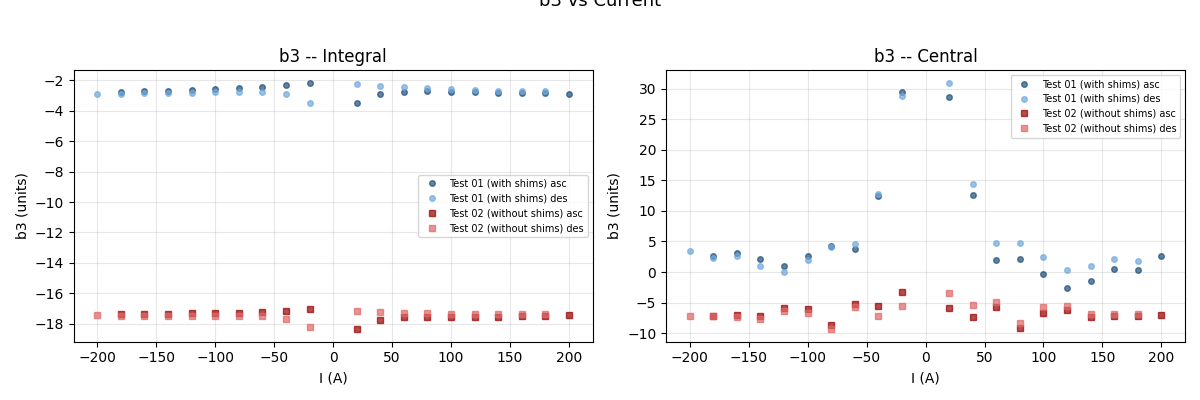

In [6]:
fig, axes = plt.subplots(1, len(SEGMENTS), figsize=(12, 4), squeeze=False)

DS_STYLES = [
    ("o", "#1f4e79", "#6fa8dc"),   # first dataset
    ("s", "#990000", "#e06666"),   # second dataset
]

for j, seg in enumerate(SEGMENTS):
    ax = axes[0, j]
    for k, (name, _) in enumerate(DS_DIRS):
        marker, c_asc, c_desc = DS_STYLES[k]
        s = summ[name][seg].copy()
        good = s[(s["quality"] == "good") & (s["I_nom"].abs() > 2)]
        for br, color in [("ascending", c_asc), ("descending", c_desc)]:
            br_data = good[good["branch"] == br].sort_values("run_id")
            if len(br_data) == 0: continue
            I_vals = br_data["I_nom"].values
            breaks = [0] + [i for i in range(1, len(I_vals))
                            if abs(I_vals[i] - I_vals[i-1]) > 30] + [len(I_vals)]
            for bi in range(len(breaks)-1):
                seg_data = br_data.iloc[breaks[bi]:breaks[bi+1]]
                ax.plot(seg_data["I_nom"], seg_data["b3_units_mean"],
                        marker=marker, ms=4, lw=0, alpha=0.7, color=color,
                        label=f"{name} {br[:3]}" if bi == 0 else "")
    ax.set_xlabel("I (A)"); ax.set_ylabel("b3 (units)")
    ax.set_title(f"b3 -- {seg}")
    ax.legend(fontsize=7, loc="best")

fig.suptitle("b3 vs Current", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 7. TF Overlay

C:\Users\albellel\AppData\Local\Temp\ipykernel_77852\2485381013.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7, loc="best")


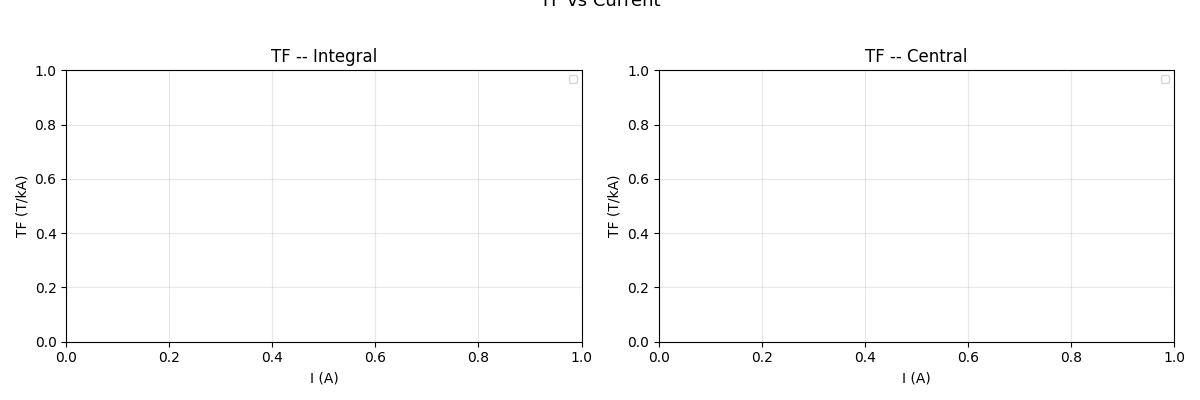

In [7]:
fig, axes = plt.subplots(1, len(SEGMENTS), figsize=(12, 4), squeeze=False)

DS_STYLES = [
    ("o", "#1f4e79", "#6fa8dc"),   # first dataset
    ("s", "#990000", "#e06666"),   # second dataset
]

for j, seg in enumerate(SEGMENTS):
    ax = axes[0, j]
    for k, (name, _) in enumerate(DS_DIRS):
        marker, c_asc, c_desc = DS_STYLES[k]
        s = summ[name][seg].copy()
    # Compute TF if not already present
    if "TF" not in s.columns:
        s["TF"] = s["B1_mean"] / (s["I_nom"] / 1000.0)

        good = s[(s["quality"] == "good") & (s["I_nom"].abs() > 2)]
        for br, color in [("ascending", c_asc), ("descending", c_desc)]:
            br_data = good[good["branch"] == br].sort_values("run_id")
            if len(br_data) == 0: continue
            I_vals = br_data["I_nom"].values
            breaks = [0] + [i for i in range(1, len(I_vals))
                            if abs(I_vals[i] - I_vals[i-1]) > 30] + [len(I_vals)]
            for bi in range(len(breaks)-1):
                seg_data = br_data.iloc[breaks[bi]:breaks[bi+1]]
                ax.plot(seg_data["I_nom"], seg_data["TF"],
                        marker=marker, ms=4, lw=0, alpha=0.7, color=color,
                        label=f"{name} {br[:3]}" if bi == 0 else "")
    ax.set_xlabel("I (A)"); ax.set_ylabel("TF (T/kA)")
    ax.set_title(f"TF -- {seg}")
    ax.legend(fontsize=7, loc="best")

fig.suptitle("TF vs Current", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 8. Per-Level Differences

Difference = (Test 02 (without shims)) - (Test 01 (with shims))

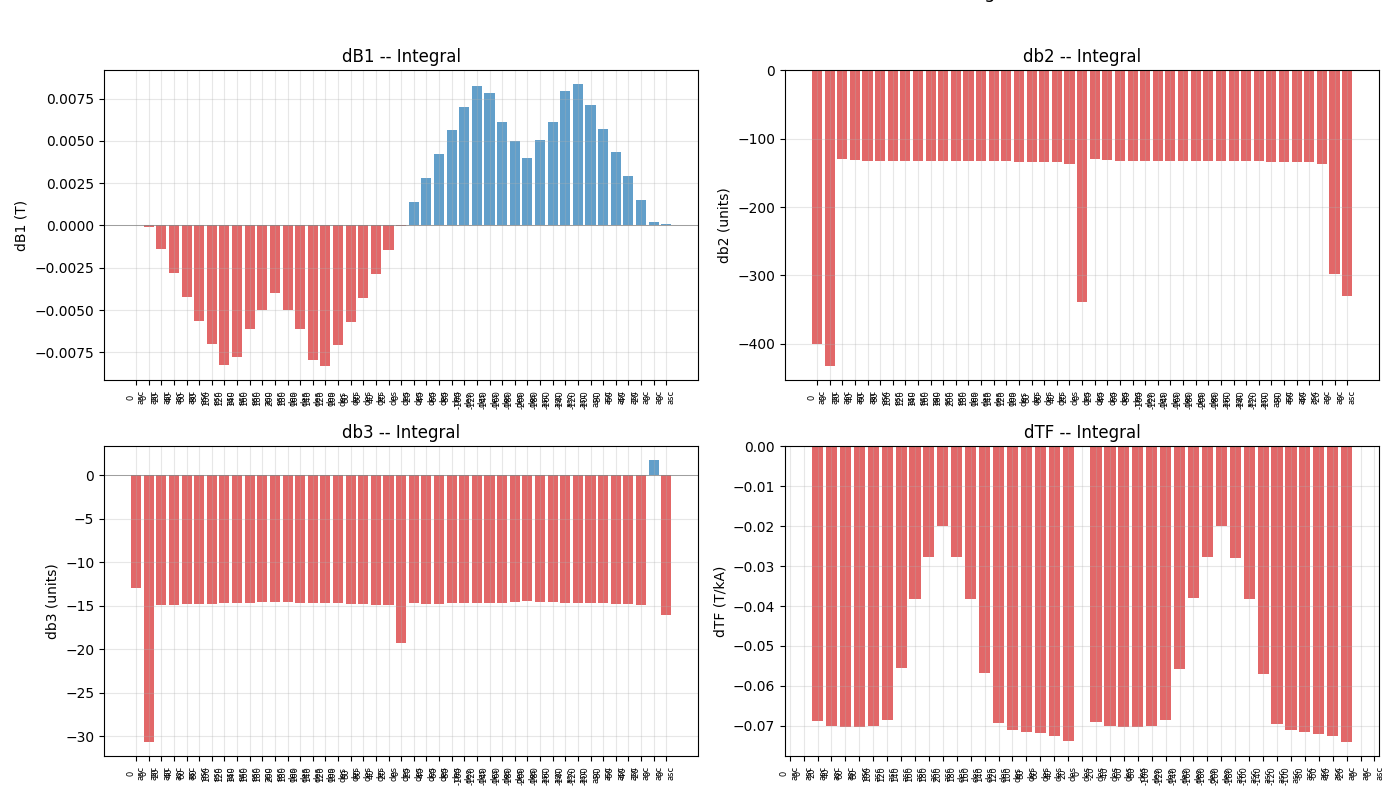


Integral -- matched runs with |I| > 2 A: 38
   dB1: max|d|=0.008334, mean|d|=0.005320, rms=0.005724
   db2: max|d|=136.359819, mean|d|=132.797550, rms=132.803628
   db3: max|d|=14.944861, mean|d|=14.719910, rms=14.720264
   dTF: max|d|=0.073976, mean|d|=0.058584, rms=0.061234


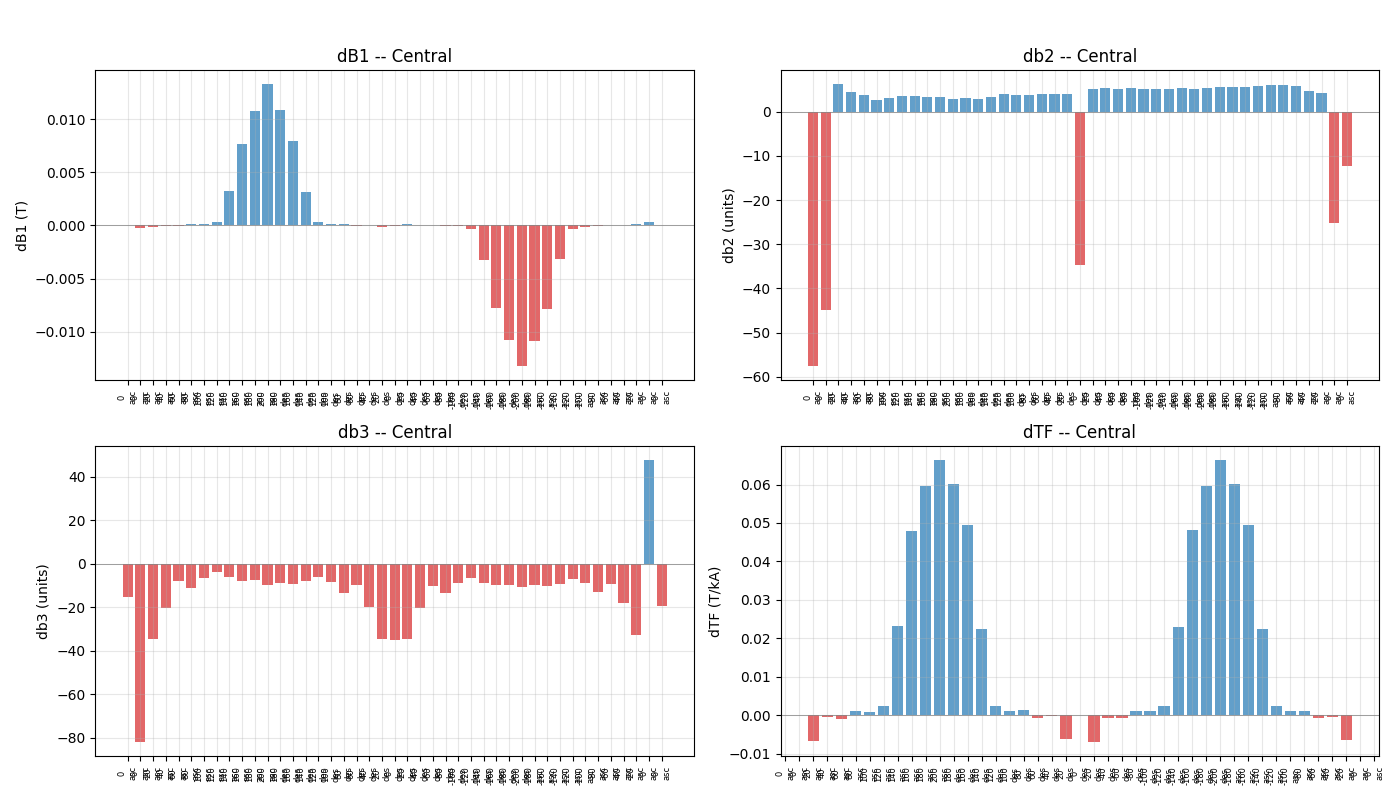


Central -- matched runs with |I| > 2 A: 38
   dB1: max|d|=0.013254, mean|d|=0.003062, rms=0.005384
   db2: max|d|=6.173467, mean|d|=4.519368, rms=4.639930
   db3: max|d|=34.507628, mean|d|=12.658772, rms=15.109227
   dTF: max|d|=0.066271, mean|d|=0.018632, rms=0.030322


In [8]:
NAME_A, NAME_B = DS_DIRS[0][0], DS_DIRS[1][0]

for seg in SEGMENTS:
    sA = summ[NAME_A][seg].copy()
    sB = summ[NAME_B][seg].copy()

    # Compute TF if missing
    for s in [sA, sB]:
        if "TF" not in s.columns:
            s["TF"] = s["B1_mean"] / (s["I_nom"] / 1000.0)

    merged = pd.merge(
        sA[sA["quality"] == "good"],
        sB[sB["quality"] == "good"],
        on=["I_nom", "branch"], suffixes=("_A", "_B"), how="inner"
    )
    if len(merged) == 0:
        print(f"No matching runs for {seg}")
        continue

    merged["dB1"] = merged["B1_mean_B"] - merged["B1_mean_A"]
    merged["db2"] = merged["b2_units_mean_B"] - merged["b2_units_mean_A"]
    merged["db3"] = merged["b3_units_mean_B"] - merged["b3_units_mean_A"]
    merged["dTF"] = merged["TF_B"] - merged["TF_A"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for ax, (col, ylabel, title) in zip(axes.flat, [
            ("dB1", "dB1 (T)", "dB1"), ("db2", "db2 (units)", "db2"),
            ("db3", "db3 (units)", "db3"), ("dTF", "dTF (T/kA)", "dTF")]):
        x_labels = [f"{row['I_nom']:.0f}\n{row['branch'][:3]}" for _, row in merged.iterrows()]
        vals = merged[col].values
        colors = ["tab:blue" if v >= 0 else "tab:red" for v in vals]
        ax.bar(range(len(vals)), vals, color=colors, alpha=0.7)
        ax.set_xticks(range(len(vals))); ax.set_xticklabels(x_labels, fontsize=6, rotation=90)
        ax.axhline(0, color="grey", linewidth=0.5)
        ax.set_ylabel(ylabel); ax.set_title(f"{title} -- {seg}")

    fig.suptitle(f"Differences ({NAME_B}) - ({NAME_A}) -- {seg}", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

    # Summary statistics
    sub = merged[merged["I_nom"].abs() > 2]
    print(f"\n{seg} -- matched runs with |I| > 2 A: {len(sub)}")
    for col in ["dB1", "db2", "db3", "dTF"]:
        vals = sub[col].values
        print(f"  {col:>4s}: max|d|={np.abs(vals).max():.6f}, "
              f"mean|d|={np.abs(vals).mean():.6f}, rms={np.sqrt((vals**2).mean()):.6f}")

---
## 9. Multipole Spectrum Comparison

Overlay at peak current for the first segment.

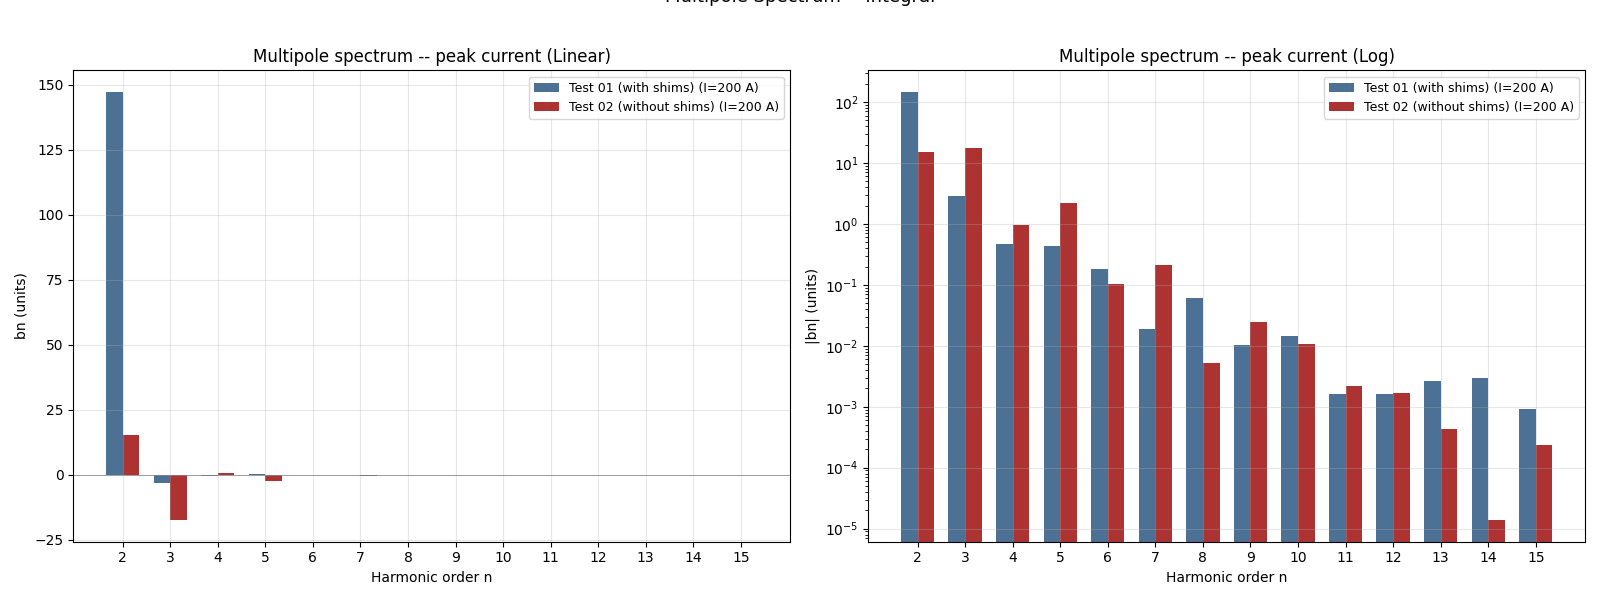

In [9]:
seg = SEGMENTS[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
orders = list(range(2, 16))

for k, (name, _) in enumerate(DS_DIRS):
    s = summ[name][seg]
    good = s[s["quality"] == "good"]
    if len(good) == 0: continue
    peak_row = good.loc[good["I_nom"].abs().idxmax()]
    means = []
    for n in orders:
        col = f"b{n}_units_mean"
        means.append(peak_row[col] if col in good.columns else 0)

    marker, c_asc, _ = DS_STYLES[k]
    x = np.arange(len(orders))
    w = 0.35
    offset = (k - 0.5) * w

    for ax_idx, (title, yscale) in enumerate([("Linear", "linear"), ("Log", "log")]):
        ax = axes[ax_idx]
        vals = [abs(v) for v in means] if yscale == "log" else means
        ax.bar(x + offset, vals, w, label=f"{name} (I={peak_row['I_nom']:.0f} A)",
               color=c_asc, alpha=0.8)

for ax_idx, (title, yscale) in enumerate([("Linear", "linear"), ("Log", "log")]):
    ax = axes[ax_idx]
    if yscale == "linear":
        ax.axhline(0, color="grey", linewidth=0.5)
    else:
        ax.set_yscale("log")
    ax.set_xticks(np.arange(len(orders))); ax.set_xticklabels(orders)
    ax.set_xlabel("Harmonic order n")
    ax.set_ylabel("bn (units)" if yscale == "linear" else "|bn| (units)")
    ax.set_title(f"Multipole spectrum -- peak current ({title})")
    ax.legend(fontsize=9)

fig.suptitle(f"Multipole Spectrum -- {seg}", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 10. Summary

In [10]:
summary_rows = []
for name, _ in DS_DIRS:
    for seg in SEGMENTS:
        s = summ[name][seg]
        good = s[s["quality"] == "good"]
        if len(good) == 0: continue
        # Peak current row
        peak = good.loc[good["I_nom"].abs().idxmax()]

        # Compute TF if missing
        if "TF" not in good.columns:
            tf_peak = peak["B1_mean"] / (peak["I_nom"] / 1000.0)
        else:
            tf_peak = peak["TF"]

        summary_rows.append({
            "Dataset": name, "Segment": seg,
            "Good runs": len(good),
            "I range (A)": f"{good['I_nom'].min():.0f} to {good['I_nom'].max():.0f}",
            "B1 peak (T)": f"{peak['B1_mean']:.6f}",
            "b2 peak": f"{peak['b2_units_mean']:+.4f}",
            "b3 peak": f"{peak['b3_units_mean']:+.4f}",
            "TF peak (T/kA)": f"{tf_peak:.4f}",
        })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

# Export
out_dir = REPO_ROOT / "output" / "MC62/compare_01_vs_02"
out_dir.mkdir(parents=True, exist_ok=True)
df_summary.to_csv(out_dir / "summary_comparison.csv", index=False)
print(f"\nWrote {out_dir / 'summary_comparison.csv'}")
print("\nDone.")

                Dataset  Segment  Good runs I range (A) B1 peak (T)   b2 peak  b3 peak TF peak (T/kA)
   Test 01 (with shims) Integral         41 -200 to 200    0.230320 +147.3739  -2.9008         1.1516
   Test 01 (with shims)  Central         41 -200 to 200    0.378428   -2.6567  +2.6954         1.8921
Test 02 (without shims) Integral         41 -200 to 200    0.226344  +15.3091 -17.4295         1.1317
Test 02 (without shims)  Central         41 -200 to 200    0.391682   +0.2923  -7.0942         1.9584

Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MC62\compare_01_vs_02\summary_comparison.csv

Done.
